# 机器学习算法实践 01：从数据到预测——完整机器学习流程实践

## 实验目的

本实验以 Iris 鸢尾花分类任务为例，完成一个完整的机器学习分类流程。

通过本实验了解机器学习中的数据、特征、标签、训练集、测试集、模型训练、模型预测和模型评价等基本概念，并掌握使用 Python 和 scikit-learn 完成基本机器学习任务的方法。

本实验重点关注机器学习的完整工作流程，为后续学习 KNN、朴素贝叶斯、逻辑回归、决策树、支持向量机等算法奠定基础。

## 1. 实验任务

Iris（鸢尾花）数据集是机器学习中经典的分类数据集。

数据集中包含三种鸢尾花：

- Setosa（山鸢尾）
- Versicolor（变色鸢尾）
- Virginica（维吉尼亚鸢尾）

每个样本包含 4 个特征：

1. 花萼长度（sepal length）
2. 花萼宽度（sepal width）
3. 花瓣长度（petal length）
4. 花瓣宽度（petal width）

本实验的目标是：

**根据一朵鸢尾花的 4 个特征，预测它属于哪一种鸢尾花。**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("环境准备完成！")

环境准备完成！


## 2. 数据加载

本实验使用 scikit-learn 内置的 Iris 数据集。

机器学习中的数据通常可以表示为：

- **X（Features）**：输入特征
- **y（Label）**：预测目标

本实验中，X 表示鸢尾花的四个测量特征，y 表示鸢尾花所属类别。

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

print("特征数据 X 的形状：", X.shape)
print("标签数据 y 的形状：", y.shape)

print("\n特征名称：")
print(iris.feature_names)

print("\n类别名称：")
print(iris.target_names)

特征数据 X 的形状： (150, 4)
标签数据 y 的形状： (150,)

特征名称：
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

类别名称：
['setosa' 'versicolor' 'virginica']


In [3]:
df = pd.DataFrame(X, columns=iris.feature_names)

df["target"] = y
df["species"] = df["target"].map({
    0: iris.target_names[0],
    1: iris.target_names[1],
    2: iris.target_names[2]
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 3. 数据探索

在训练机器学习模型之前，需要首先了解数据的基本情况，包括数据规模、数据类型、缺失值以及各类别样本数量。

In [4]:
print("数据集大小：", df.shape)

print("\n前 5 条数据：")
print(df.head())

print("\n数据基本信息：")
df.info()

print("\n缺失值数量：")
print(df.isnull().sum())

print("\n各类别样本数量：")
print(df["species"].value_counts())

数据集大小： (150, 6)

前 5 条数据：
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  

数据基本信息：
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null 

In [5]:
df[iris.feature_names].describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


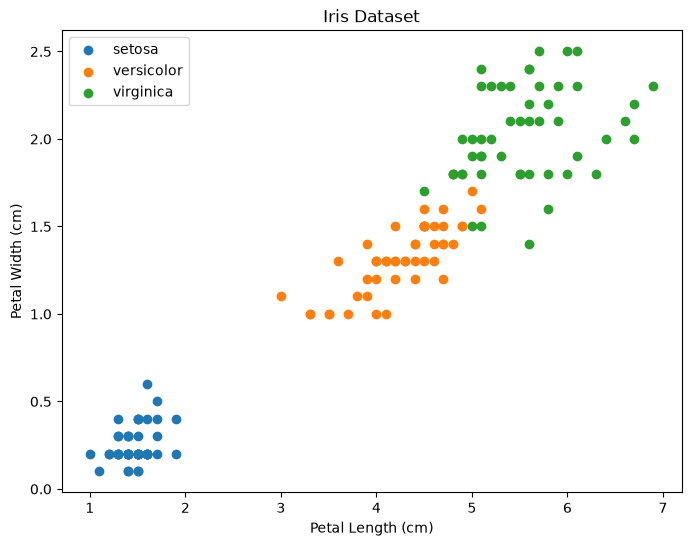

In [6]:
plt.figure(figsize=(8, 6))

for i, species in enumerate(iris.target_names):
    subset = df[df["target"] == i]

    plt.scatter(
        subset["petal length (cm)"],
        subset["petal width (cm)"],
        label=species
    )

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Iris Dataset")
plt.legend()
plt.show()

## 4. 划分训练集和测试集

为了评价模型对未知数据的预测能力，不能直接使用全部数据训练模型。

因此将数据划分为：

- **训练集（Training Set）**：用于训练模型
- **测试集（Test Set）**：用于评价模型

本实验按照 80% : 20% 的比例划分数据。

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("训练集特征形状：", X_train.shape)
print("测试集特征形状：", X_test.shape)

print("训练集标签形状：", y_train.shape)
print("测试集标签形状：", y_test.shape)

训练集特征形状： (120, 4)
测试集特征形状： (30, 4)
训练集标签形状： (120,)
测试集标签形状： (30,)


## 5. 模型训练

本实验使用 Logistic Regression 作为分类模型。

第一周暂时将模型看作一个“黑盒”，重点理解模型训练的基本过程。

模型通过训练数据 X_train 和对应标签 y_train 学习特征与类别之间的关系。

In [8]:
model = LogisticRegression(max_iter=200)

model.fit(X_train, y_train)

print("模型训练完成！")

模型训练完成！


## 6. 模型预测

模型训练完成后，将测试集 X_test 输入模型，得到预测结果。

In [9]:
y_pred = model.predict(X_test)

print("真实标签：")
print(y_test)

print("\n预测标签：")
print(y_pred)

真实标签：
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]

预测标签：
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


In [10]:
accuracy = accuracy_score(y_test, y_pred)

print(f"模型准确率：{accuracy:.2%}")

模型准确率：96.67%


In [11]:
result = pd.DataFrame({
    "真实类别": [iris.target_names[i] for i in y_test],
    "预测类别": [iris.target_names[i] for i in y_pred]
})

result["预测是否正确"] = result["真实类别"] == result["预测类别"]

result

,真实类别,预测类别,预测是否正确
0,setosa,setosa,True
1,virginica,virginica,True
2,versicolor,versicolor,True
3,versicolor,versicolor,True
4,setosa,setosa,True
5,versicolor,versicolor,True
6,setosa,setosa,True
7,setosa,setosa,True
8,virginica,virginica,True
9,versicolor,versicolor,True


## 7. 模型评价

除了准确率，还可以使用混淆矩阵观察模型在不同类别上的预测情况。

混淆矩阵中的行表示真实类别，列表示预测类别。

In [12]:
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=iris.target_names,
    columns=iris.target_names
)

cm_df

,setosa,versicolor,virginica
setosa,10,0,0
versicolor,0,9,1
virginica,0,0,10


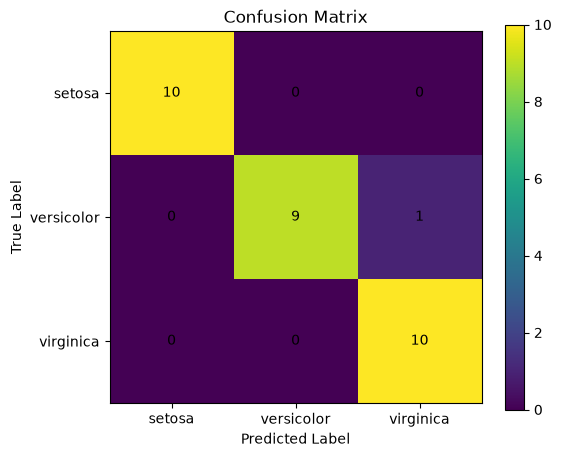

In [13]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.xticks(
    range(len(iris.target_names)),
    iris.target_names
)

plt.yticks(
    range(len(iris.target_names)),
    iris.target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

In [14]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## 8. 实验结果分析

本实验将 Iris 数据集按照 80% : 20% 的比例划分为训练集和测试集，其中训练集包含 120 个样本，测试集包含 30 个样本。使用 Logistic Regression 模型完成训练后，在测试集上的分类准确率达到 **96.67%**，即 30 个测试样本中有 29 个被正确分类。

从混淆矩阵可以看出：

- Setosa 类别的 10 个测试样本全部被正确分类，分类正确率为 100%；
- Versicolor 类别的 10 个测试样本中有 9 个被正确分类，其中 1 个被错误预测为 Virginica；
- Virginica 类别的 10 个测试样本全部被正确分类。

因此，本次实验唯一的分类错误发生在 Versicolor 和 Virginica 之间。这与前面的数据可视化结果相符：Setosa 在花瓣长度和花瓣宽度等特征上与另外两类存在较明显的差异，而 Versicolor 和 Virginica 的特征分布存在一定重叠，因此两者更容易出现分类混淆。

从分类报告来看，三个类别整体均取得了较好的 Precision、Recall 和 F1-score。其中 Setosa 的 Precision、Recall 和 F1-score 均为 1.00；Versicolor 的 Recall 为 0.90；Virginica 的 Precision 为 0.91。模型整体的 Accuracy、Macro Average F1-score 和 Weighted Average F1-score 均约为 0.97。

综合实验结果可以看出，利用鸢尾花的花萼和花瓣特征能够较好地区分不同种类的鸢尾花，同时也说明训练集与测试集划分、模型训练、模型预测和模型评价共同构成了一个完整的机器学习分类流程。

## 9. 实验总结

本实验以经典的 Iris 鸢尾花分类任务为例，完成了一个基本机器学习项目从数据到预测的完整流程，包括数据加载、数据探索、数据可视化、训练集与测试集划分、模型训练、模型预测以及模型评价。

实验将 150 个鸢尾花样本按照 80% : 20% 的比例划分为训练集和测试集，并使用 Logistic Regression 完成分类。在 30 个测试样本中，模型正确预测了 29 个样本，准确率达到 96.67%。混淆矩阵显示，唯一的分类错误为一个 Versicolor 样本被预测为 Virginica。

通过本次实验，我理解了特征（Features）、标签（Label）、训练集（Training Set）、测试集（Test Set）、模型训练（Fit）、模型预测（Predict）以及模型评价（Evaluation）等机器学习中的基本概念，并掌握了使用 scikit-learn 完成基本分类任务的方法。

本实验的重点是理解机器学习的整体工作流程，因此暂未深入讨论 Logistic Regression 的数学原理。后续实验将在此基础上进一步学习和实现具体的机器学习算法。